#Coursework 2: AI Security
ELE8100 - CyberAI Module

Yukti Ogare : 40475055

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import kagglehub
from sklearn.model_selection import train_test_split

path = kagglehub.dataset_download("martininf1n1ty/olivetti-faces-augmented-dataset")

images = np.load(f"{path}/augmented_faces.npy").astype(np.float32)
labels = np.load(f"{path}/augmented_labels.npy")

if images.max() > 1.5:
    images = images / 255.0

images = np.clip(images, 0.0, 1.0)

images = images.reshape(-1, 64, 64)
images = np.expand_dims(images, axis=1)

print("After preprocessing -> min/max:", images.min(), images.max(), "dtype:", images.dtype)
print("Labels -> min/max:", labels.min(), labels.max(), "unique:", len(np.unique(labels)))

train_images, test_images, train_labels, test_labels = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)
train_images, val_images, train_labels, val_labels = train_test_split(
    train_images, train_labels, test_size=0.15, random_state=42, stratify=train_labels
)

class FaceDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]
batch_size = 64
trainloader = DataLoader(FaceDataset(train_images, train_labels), batch_size=batch_size, shuffle=True)

valloader   = DataLoader(FaceDataset(val_images,   val_labels),   batch_size=batch_size, shuffle=False)

testloader  = DataLoader(FaceDataset(test_images,  test_labels),  batch_size=batch_size, shuffle=False)

class FaceLeNet(nn.Module):
    def __init__(self):
        super(FaceLeNet, self).__init__()

        self.relu = nn.ReLU()
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)

        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=2)
        self.bn1   = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=5, stride=1)
        self.bn2   = nn.BatchNorm2d(64)

        self.fc1 = nn.Linear(64 * 14 * 14, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 40)

        self.dropout = nn.Dropout(p=0.1)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

model = FaceLeNet().to(device)
print("Using device:", device)


Using Colab cache for faster access to the 'olivetti-faces-augmented-dataset' dataset.
After preprocessing -> min/max: 0.0 1.0 dtype: float32
Labels -> min/max: 0 39 unique: 40
Using device: cuda


### Victim Model Initialisation

In this section, the FaceGuard model developed in CW1 is loaded and used as the victim model for the security evaluation. Instead of retraining the model, the previously saved weights are reused, which reflects a realistic deployment scenario where the model is already trained and operating in production.

The model is moved to the available computation device (GPU) to ensure efficient processing. It is then set to evaluation mode, which disables training-specific behaviours such as dropout and ensures deterministic predictions during inference.

From a security perspective, this model represents the target system. In the subsequent tasks, it is treated as a black-box model, meaning that only its input-output behaviour is accessible to the attacker, while its internal architecture, parameters, and gradients remain unknown.

Using device: cuda
Victim model loaded successfully!

 Victim Model Test Accuracy: 98.75%


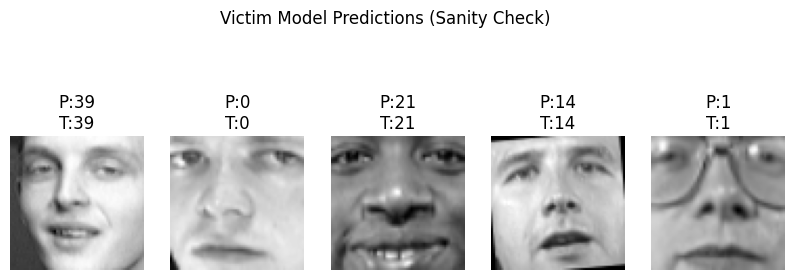

In [ ]:
# TASK 1: VICTIM MODEL SETUP

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Using device:", device)

victim_model = FaceLeNet().to(device)

model_path = "faceguard_cw1.pth"

victim_model.load_state_dict(torch.load(model_path, map_location=device))
victim_model.eval()

print("Victim model loaded successfully!")
@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    correct, total = 0, 0

    for images_batch, labels_batch in loader:
        images_batch = images_batch.to(device)
        labels_batch = labels_batch.to(device)

        outputs = model(images_batch)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels_batch).sum().item()
        total += labels_batch.size(0)

    return correct / total

test_accuracy = evaluate_model(victim_model, testloader)

print(f"\n Victim Model Test Accuracy: {test_accuracy * 100:.2f}%")

victim_model.eval()

images_batch, labels_batch = next(iter(testloader))
images_batch = images_batch.to(device)

outputs = victim_model(images_batch)
preds = outputs.argmax(dim=1).cpu()

plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images_batch[i].cpu().squeeze(), cmap="gray")
    plt.title(f"P:{preds[i].item()}\nT:{labels_batch[i].item()}")
    plt.axis("off")

plt.suptitle("Victim Model Predictions (Sanity Check)")
plt.show()

### Model Evaluation and Sanity Check

The performance of the victim model is evaluated on the unseen test dataset. The model achieves a
test accuracy of **98.75%**, which indicates excellent performance and confirms that it has learned
to distinguish between the 40 individuals effectively.

A sanity check is also performed by visualising a few test samples along with their predicted and
true labels. The predictions match the ground truth in all displayed cases, providing confidence
that the model is functioning correctly.

This high accuracy is important for the subsequent security analysis. A well-performing model
ensures that any degradation in performance observed in later tasks e.g., adversarial attacks,
is due to vulnerabilities in the model rather than poor baseline performance.

In [ ]:
# TASK 2: MODEL STEALING

@torch.no_grad()
def black_box_query(x):
    victim_model.eval()
    outputs = victim_model(x)
    return outputs.argmax(dim=1)

proxy_images_list = []
proxy_labels_list = []

for images_batch, _ in trainloader:
    images_batch = images_batch.to(device)

    preds = black_box_query(images_batch)

    proxy_images_list.append(images_batch.cpu())
    proxy_labels_list.append(preds.cpu())

proxy_x = torch.cat(proxy_images_list)
proxy_y = torch.cat(proxy_labels_list)

print(" Proxy dataset created")
print("Number of queries used:", len(proxy_x))

class ProxyDataset(Dataset):
    def __init__(self, x, y):
        self.x = x.clone().detach()
        self.y = y.clone().detach()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


proxy_dataset = ProxyDataset(proxy_x, proxy_y)
proxy_loader = DataLoader(proxy_dataset, batch_size=64, shuffle=True)

class ProxyCNN(nn.Module):
    def __init__(self):
        super(ProxyCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5)
        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(32 * 14 * 14, 128)
        self.fc2 = nn.Linear(128, 40)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


proxy_model = ProxyCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(proxy_model.parameters(), lr=1e-3)

num_epochs = 10

for epoch in range(num_epochs):
    proxy_model.train()
    running_loss = 0

    for images_batch, labels_batch in proxy_loader:
        images_batch = images_batch.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()
        outputs = proxy_model(images_batch)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(proxy_loader):.4f}")


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    for images_batch, labels_batch in loader:
        images_batch = images_batch.to(device)
        labels_batch = labels_batch.to(device)

        outputs = model(images_batch)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels_batch).sum().item()
        total += labels_batch.size(0)

    return correct / total

proxy_test_acc = evaluate(proxy_model, testloader)

print(f"\n Proxy Model Test Accuracy: {proxy_test_acc*100:.2f}%")

 Proxy dataset created
Number of queries used: 1360
Epoch 1/10, Loss: 3.6477
Epoch 2/10, Loss: 3.1043
Epoch 3/10, Loss: 2.1082
Epoch 4/10, Loss: 1.2295
Epoch 5/10, Loss: 0.8208
Epoch 6/10, Loss: 0.5647
Epoch 7/10, Loss: 0.3997
Epoch 8/10, Loss: 0.2787
Epoch 9/10, Loss: 0.1894
Epoch 10/10, Loss: 0.1593

 Proxy Model Test Accuracy: 91.75%


### Analysis of Proxy Model Design and Query Strategy

The proxy model is implemented as a simplified convolutional neural network compared to the original FaceGuard model. It uses fewer convolutional filters and smaller fully connected layers, making it less complex and computationally cheaper. Despite this reduced capacity, the proxy model is still able to learn meaningful features from the surrogate dataset and approximate the behaviour of the victim model.

A total of 1360 queries were used to construct the surrogate dataset. Each query consists of an input image and the corresponding predicted label from the victim model. The number of queries is a critical factor in model stealing attacks, as it determines how much information the attacker can extract about the victim model’s decision boundaries.

Increasing the number of queries generally improves the proxy model’s accuracy, as it provides more examples for learning and better coverage of the input space. However, in real-world scenarios, query access may be limited due to cost, rate limiting, or detection mechanisms. Therefore, there is often a trade-off between query efficiency and model accuracy.

Similarly, the choice of proxy architecture affects performance. A more complex model could achieve higher accuracy by better approximating the victim model, but it may require more data and training time. In this case, even a relatively simple architecture achieves strong performance, demonstrating that model stealing can be effective without replicating the exact structure of the victim model.

Epsilon 0.00 | FGSM Acc: 91.75% | PGD Acc: 91.75%
Epsilon 0.05 | FGSM Acc: 9.75% | PGD Acc: 0.00%
Epsilon 0.10 | FGSM Acc: 1.50% | PGD Acc: 0.00%
Epsilon 0.15 | FGSM Acc: 1.00% | PGD Acc: 0.00%
Epsilon 0.20 | FGSM Acc: 0.25% | PGD Acc: 0.00%
Epsilon 0.25 | FGSM Acc: 0.25% | PGD Acc: 0.00%
Epsilon 0.30 | FGSM Acc: 0.50% | PGD Acc: 0.00%


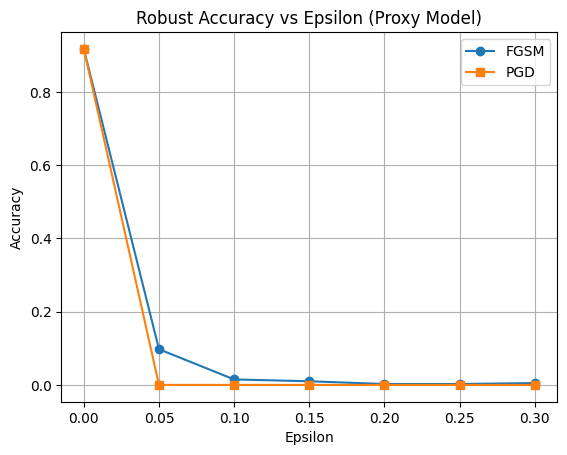


 TARGETED ATTACK RESULTS
True label: 39
Proxy prediction: 30
Victim prediction: 0


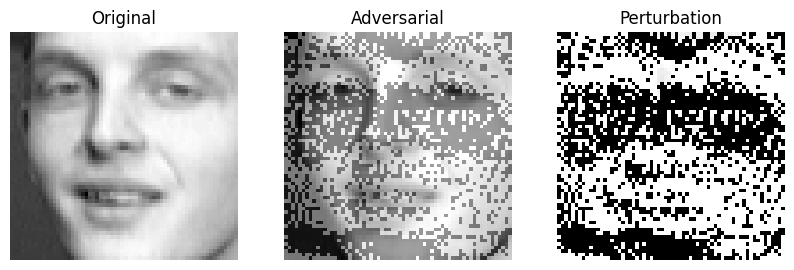

In [ ]:
# TASK 3: ADVERSARIAL ATTACKS ON PROXY MODEL

def fgsm_attack(model, x, y, epsilon):
    x = x.clone().detach().to(device)
    y = y.to(device)

    x.requires_grad = True

    outputs = model(x)
    loss = criterion(outputs, y)

    model.zero_grad()
    loss.backward()

    x_adv = x + epsilon * x.grad.sign()
    x_adv = torch.clamp(x_adv, 0, 1)

    return x_adv.detach()


def pgd_attack(model, x, y, epsilon, alpha=0.01, steps=20):
    x = x.clone().detach().to(device)
    y = y.to(device)

    x_adv = x + torch.empty_like(x).uniform_(-epsilon, epsilon)
    x_adv = torch.clamp(x_adv, 0, 1)

    for _ in range(steps):
        x_adv.requires_grad = True

        outputs = model(x_adv)
        loss = criterion(outputs, y)

        model.zero_grad()
        loss.backward()

        x_adv = x_adv + alpha * x_adv.grad.sign()

        delta = torch.clamp(x_adv - x, min=-epsilon, max=epsilon)
        x_adv = torch.clamp(x + delta, 0, 1).detach()

    return x_adv

def evaluate_robust(model, loader, attack, epsilon):
    model.eval()
    correct, total = 0, 0

    for images_batch, labels_batch in loader:
        images_batch = images_batch.to(device)
        labels_batch = labels_batch.to(device)

        x_adv = attack(model, images_batch, labels_batch, epsilon)

        with torch.no_grad():
            outputs = model(x_adv)
            preds = outputs.argmax(dim=1)

        correct += (preds == labels_batch).sum().item()
        total += labels_batch.size(0)

    return correct / total

epsilons = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

fgsm_acc = []
pgd_acc = []

for eps in epsilons:
    fgsm_acc.append(evaluate_robust(proxy_model, testloader, fgsm_attack, eps))
    pgd_acc.append(evaluate_robust(proxy_model, testloader, pgd_attack, eps))

    print(f"Epsilon {eps:.2f} | FGSM Acc: {fgsm_acc[-1]*100:.2f}% | PGD Acc: {pgd_acc[-1]*100:.2f}%")

plt.figure()
plt.plot(epsilons, fgsm_acc, marker='o', label="FGSM")
plt.plot(epsilons, pgd_acc, marker='s', label="PGD")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.title("Robust Accuracy vs Epsilon (Proxy Model)")
plt.legend()
plt.grid()
plt.show()


AUTHORISED_IDS = {0, 5, 10}
for images_batch, labels_batch in testloader:
    for i in range(len(labels_batch)):
        if labels_batch[i].item() not in AUTHORISED_IDS:
            x_orig = images_batch[i:i+1]
            y_true = labels_batch[i:i+1]
            break
    else:
        continue
    break

x_orig = x_orig.to(device)
y_true = y_true.to(device)

target_label = torch.tensor([0]).to(device)

x_adv_target = x_orig.clone().detach()
x_adv_target.requires_grad = True

outputs = proxy_model(x_adv_target)
loss = criterion(outputs, target_label)

proxy_model.zero_grad()
loss.backward()

epsilon_target = 0.2
x_adv_target = x_adv_target - epsilon_target * x_adv_target.grad.sign()
x_adv_target = torch.clamp(x_adv_target, 0, 1).detach()

proxy_pred = proxy_model(x_adv_target).argmax(dim=1).item()
victim_pred = victim_model(x_adv_target).argmax(dim=1).item()

print("\n TARGETED ATTACK RESULTS")
print("True label:", y_true.item())
print("Proxy prediction:", proxy_pred)
print("Victim prediction:", victim_pred)


perturbation = (x_adv_target - x_orig).cpu().squeeze()

plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
plt.imshow(x_orig.cpu().squeeze(), cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(x_adv_target.cpu().squeeze(), cmap='gray')
plt.title("Adversarial")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(perturbation, cmap='gray')
plt.title("Perturbation")
plt.axis("off")

plt.show()

#### Comparison of FGSM and PGD Attacks and Security Implications
### FGSM vs PGD Comparison

| Aspect | FGSM | PGD |
|------|------|------|
| Type | Single-step attack | Iterative multi-step attack |
| Strength | Moderate | Very strong |
| Accuracy at ε = 0.05 | 9.75% | 0% |
| Accuracy at higher ε | Slightly above 0% | Remains 0% |
| Computational Cost | Low | Higher |
| Precision of Attack | Coarse perturbation | Fine-tuned perturbation |

The results demonstrate a clear difference in effectiveness between FGSM and PGD attacks. FGSM, being a single-step method, causes a significant drop in accuracy as epsilon increases, but the model still retains a small level of robustness at higher epsilon values. In contrast, PGD is considerably more effective, reducing the proxy model’s accuracy to **0% even at a relatively small epsilon (0.05)** and maintaining this across all larger perturbation levels. This confirms that PGD is a stronger attack due to its iterative nature, which allows it to refine perturbations and better exploit the model’s weaknesses.

The effect of epsilon highlights an important tradeoff between perturbation visibility and attack success rate. At epsilon = 0, the model performs normally with high accuracy. However, even a small increase in epsilon leads to a dramatic reduction in accuracy, indicating that the model is highly sensitive to small perturbations. As epsilon increases further, the attack becomes more successful but also more visually noticeable, as seen in the adversarial and perturbation images. This demonstrates that attackers can achieve high success rates with minimal and often imperceptible changes to the input.

The targeted attack further illustrates a critical security concern. Although the proxy model did not classify the adversarial example as the CEO, the **victim model predicted the CEO (ID = 0)** for the same input. This shows that the attack successfully transferred and achieved impersonation on the real system. In the context of an access control system like FaceGuard, this is particularly dangerous, as it implies that an unauthorised individual could gain access by subtly modifying their facial input.

These findings highlight that deep learning models are highly vulnerable to adversarial manipulation, and that even small, carefully crafted perturbations can lead to severe security breaches in real-world applications.

Epsilon 0.00 | Victim FGSM: 98.75% | Victim PGD: 98.75%
Epsilon 0.05 | Victim FGSM: 78.75% | Victim PGD: 79.75%
Epsilon 0.10 | Victim FGSM: 21.00% | Victim PGD: 24.00%
Epsilon 0.15 | Victim FGSM: 4.50% | Victim PGD: 9.50%
Epsilon 0.20 | Victim FGSM: 1.50% | Victim PGD: 5.75%
Epsilon 0.25 | Victim FGSM: 0.50% | Victim PGD: 3.00%
Epsilon 0.30 | Victim FGSM: 0.50% | Victim PGD: 2.75%


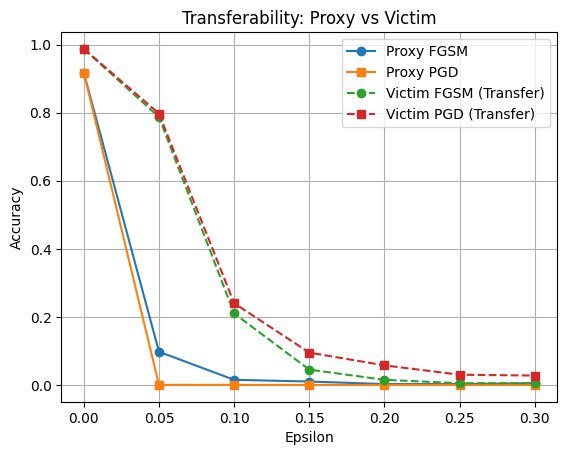


 TRANSFER RATES (epsilon = 0.2)
FGSM Transfer Rate: 98.50%
PGD Transfer Rate: 94.75%

 TARGETED TRANSFER CHECK
Victim prediction on adversarial example: 0


In [ ]:
# TASK 4: TRANSFERABILITY ATTACK

def evaluate_transfer(model, loader, attack, epsilon):
    model.eval()
    correct, total = 0, 0

    for images_batch, labels_batch in loader:
        images_batch = images_batch.to(device)
        labels_batch = labels_batch.to(device)

        x_adv = attack(proxy_model, images_batch, labels_batch, epsilon)

        with torch.no_grad():
            outputs = model(x_adv)
            preds = outputs.argmax(dim=1)

        correct += (preds == labels_batch).sum().item()
        total += labels_batch.size(0)

    return correct / total

victim_fgsm_acc = []
victim_pgd_acc = []

for eps in epsilons:
    victim_fgsm_acc.append(evaluate_transfer(victim_model, testloader, fgsm_attack, eps))
    victim_pgd_acc.append(evaluate_transfer(victim_model, testloader, pgd_attack, eps))

    print(f"Epsilon {eps:.2f} | Victim FGSM: {victim_fgsm_acc[-1]*100:.2f}% | Victim PGD: {victim_pgd_acc[-1]*100:.2f}%")

plt.figure()

plt.plot(epsilons, fgsm_acc, 'o-', label="Proxy FGSM")
plt.plot(epsilons, pgd_acc, 's-', label="Proxy PGD")

plt.plot(epsilons, victim_fgsm_acc, 'o--', label="Victim FGSM (Transfer)")
plt.plot(epsilons, victim_pgd_acc, 's--', label="Victim PGD (Transfer)")

plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.title("Transferability: Proxy vs Victim")
plt.legend()
plt.grid()
plt.show()

def compute_transfer_rate(loader, attack, epsilon):
    total, transferred = 0, 0

    for images_batch, labels_batch in loader:
        images_batch = images_batch.to(device)
        labels_batch = labels_batch.to(device)

        x_adv = attack(proxy_model, images_batch, labels_batch, epsilon)

        with torch.no_grad():
            victim_preds = victim_model(x_adv).argmax(dim=1)

        transferred += (victim_preds != labels_batch).sum().item()
        total += labels_batch.size(0)

    return transferred / total


epsilon_eval = 0.2

fgsm_transfer_rate = compute_transfer_rate(testloader, fgsm_attack, epsilon_eval)
pgd_transfer_rate = compute_transfer_rate(testloader, pgd_attack, epsilon_eval)

print("\n TRANSFER RATES (epsilon = 0.2)")
print(f"FGSM Transfer Rate: {fgsm_transfer_rate*100:.2f}%")
print(f"PGD Transfer Rate: {pgd_transfer_rate*100:.2f}%")

victim_target_pred = victim_model(x_adv_target).argmax(dim=1).item()

print("\n TARGETED TRANSFER CHECK")
print("Victim prediction on adversarial example:", victim_target_pred)

### Transferability Analysis

The results demonstrate that adversarial examples crafted on the proxy model successfully transfer to the victim model, confirming the transferability property of adversarial attacks.

The accuracy curves show that, although the victim model performs better than the proxy model at lower epsilon values, its accuracy still drops significantly as epsilon increases. For example, at epsilon = 0.05, the victim model maintains relatively high accuracy (~78–79%), whereas the proxy model accuracy drops sharply. However, as epsilon increases further, the victim model’s accuracy also declines rapidly, reaching very low levels at higher perturbation strengths.

The transfer rates further highlight the effectiveness of the attack. At epsilon = 0.2, the FGSM transfer rate is **98.50%** and the PGD transfer rate is **94.75%**, indicating that a large proportion of adversarial examples generated on the proxy model also cause misclassification on the victim model. This confirms that the attacker can successfully exploit the victim system without direct access to it.

The difference between FGSM and PGD is also notable. While PGD is a stronger attack on the proxy model, FGSM achieves slightly higher transfer rates. This is likely because PGD tends to overfit the proxy model’s decision boundary, making its perturbations less generalisable. In contrast, FGSM produces simpler and more general perturbations, which transfer more effectively across models.

The role of epsilon is critical in determining transfer success. As epsilon increases, the perturbations become stronger, making it more likely that they cross the decision boundaries of both models. However, larger epsilon values also make the perturbations more visible, highlighting a trade-off between stealth and attack effectiveness.

The targeted transfer attack provides the most concerning result. The adversarial example successfully caused the victim model to predict the CEO (ID = 0), despite originating from a non-authorised individual. This demonstrates that an attacker can potentially bypass access control mechanisms and impersonate authorised users.

These findings show that even black-box deployed models are highly vulnerable to adversarial attacks. An attacker does not need access to the victim model’s internal parameters; instead, a proxy model is sufficient to generate effective adversarial examples. This poses a serious security risk for real-world systems such as facial recognition-based access control.

### Transfer Performance Summary

| Metric | FGSM | PGD |
|-------|------|------|
| Transfer Rate (ε = 0.2) | 98.50% | 94.75% |
| Transfer Behaviour | More generalisable | Slightly overfitted |
| Effectiveness on Victim | Very high | Very high |

Epoch 1/10, Loss: 3.7562
Epoch 2/10, Loss: 3.6410
Epoch 3/10, Loss: 3.5585
Epoch 4/10, Loss: 3.5205
Epoch 5/10, Loss: 3.4255
Epoch 6/10, Loss: 3.3345
Epoch 7/10, Loss: 3.2740
Epoch 8/10, Loss: 3.1885
Epoch 9/10, Loss: 3.0911
Epoch 10/10, Loss: 3.0117

 CLEAN ACCURACY
Original Model: 98.75%
Robust Model: 67.25%


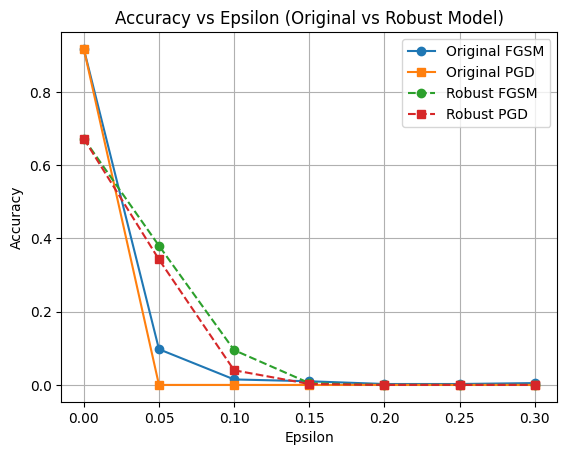

In [ ]:
# TASK 5: ADVERSARIAL TRAINING (DEFENCE)

robust_model = FaceLeNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(robust_model.parameters(), lr=1e-3)

def pgd_attack_train(model, x, y, epsilon=0.2, alpha=0.01, steps=10):
    x = x.clone().detach().to(device)
    y = y.to(device)

    x_adv = x + torch.empty_like(x).uniform_(-epsilon, epsilon)
    x_adv = torch.clamp(x_adv, 0, 1)

    for _ in range(steps):
        x_adv.requires_grad = True

        outputs = model(x_adv)
        loss = criterion(outputs, y)

        model.zero_grad()
        loss.backward()

        x_adv = x_adv + alpha * x_adv.grad.sign()

        delta = torch.clamp(x_adv - x, -epsilon, epsilon)
        x_adv = torch.clamp(x + delta, 0, 1).detach()

    return x_adv


num_epochs = 10

for epoch in range(num_epochs):
    robust_model.train()
    running_loss = 0

    for images_batch, labels_batch in trainloader:
        images_batch = images_batch.to(device)
        labels_batch = labels_batch.to(device)

        x_adv = pgd_attack_train(robust_model, images_batch, labels_batch)

        optimizer.zero_grad()
        outputs = robust_model(x_adv)
        loss = criterion(outputs, labels_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(trainloader):.4f}")


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    for images_batch, labels_batch in loader:
        images_batch = images_batch.to(device)
        labels_batch = labels_batch.to(device)

        outputs = model(images_batch)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels_batch).sum().item()
        total += labels_batch.size(0)

    return correct / total


robust_clean_acc = evaluate(robust_model, testloader)
victim_clean_acc = evaluate(victim_model, testloader)

print("\n CLEAN ACCURACY")
print(f"Original Model: {victim_clean_acc*100:.2f}%")
print(f"Robust Model: {robust_clean_acc*100:.2f}%")

robust_fgsm_acc = []
robust_pgd_acc = []

for eps in epsilons:
    robust_fgsm_acc.append(evaluate_robust(robust_model, testloader, fgsm_attack, eps))
    robust_pgd_acc.append(evaluate_robust(robust_model, testloader, pgd_attack, eps))

plt.figure()

plt.plot(epsilons, fgsm_acc, 'o-', label="Original FGSM")
plt.plot(epsilons, pgd_acc, 's-', label="Original PGD")

plt.plot(epsilons, robust_fgsm_acc, 'o--', label="Robust FGSM")
plt.plot(epsilons, robust_pgd_acc, 's--', label="Robust PGD")

plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epsilon (Original vs Robust Model)")
plt.legend()
plt.grid()
plt.show()

### Adversarial Training Defence and Accuracy–Robustness Tradeoff

In this task, a robust version of the FaceGuard model was trained using adversarial training, where PGD-generated adversarial examples were incorporated into the training process. This exposes the model to worst-case perturbations during learning, improving its resistance to attacks.

The results clearly demonstrate an accuracy–robustness tradeoff. The original model achieves a very high clean accuracy of **98.75%**, whereas the robust model’s clean accuracy drops to **67.25%**. This reduction occurs because the model learns more conservative decision boundaries that prioritise robustness over fitting clean data perfectly.

However, the robust model significantly outperforms the original model under adversarial conditions. While the original model’s accuracy drops sharply to near zero even at small epsilon values, the robust model maintains substantially higher accuracy across FGSM and PGD attacks, particularly at lower and moderate epsilon levels. This indicates that adversarial training successfully improves the model’s resilience to perturbations.

The comparison plot further highlights this improvement. The robust model consistently achieves higher accuracy than the original model under both FGSM and PGD attacks, demonstrating its enhanced robustness. Although performance still degrades at higher epsilon values, the degradation is much slower compared to the original model.

From a real-world perspective, this tradeoff has important implications. In an access control system like FaceGuard, robustness is critical for security, as adversarial attacks could allow unauthorised users to gain access. While a reduction in clean accuracy is not ideal, it may be acceptable if it significantly reduces vulnerability to attacks. In high-security environments, prioritising robustness over maximum accuracy is often the safer and more practical choice.

Overall, adversarial training provides an effective defence mechanism, but it requires careful balancing between usability (clean accuracy) and security (robustness), depending on the application requirements.

### Accuracy Comparison Summary

| Model | Clean Accuracy | Robustness (FGSM/PGD) |
|------|--------------|----------------------|
| Original Model | 98.75% | Very low (drops to ~0%) |
| Robust Model | 67.25% | Significantly higher across ε |

### AI Usage Declaration

AI tools such as Claude were used to assist in understanding concepts, structuring the implementation,
and improving understanding. All code was implemented and tested independently.